In [1]:
# ============================================
# 1. Import Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score


# ============================================
# 2. Load Dataset
# ============================================

df = pd.read_csv("daily-max-temperatures.csv")

# Display first rows
df.head()

,Date,Temperature
0,1981-01-01,38.1
1,1981-01-02,32.4
2,1981-01-03,34.5
3,1981-01-04,20.7
4,1981-01-05,21.5


In [2]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         3650 non-null   str    
 1   Temperature  3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 92.8 KB


,Temperature
count,3650.000000
mean,20.009151
std,6.108353
min,7.000000
25%,15.400000
50%,18.900000
75%,23.000000
max,43.300000


In [3]:
# Rename columns if required
df.columns = ["Date", "Temperature"]

# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

# Check missing values
df.isnull().sum()

Date           0
Temperature    0
dtype: int64

In [4]:
X = df[["Temperature"]]

# Standardise values
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[2.96206313],
       [2.02878689],
       [2.3726255 ],
       [0.11311461],
       [0.24410074]])

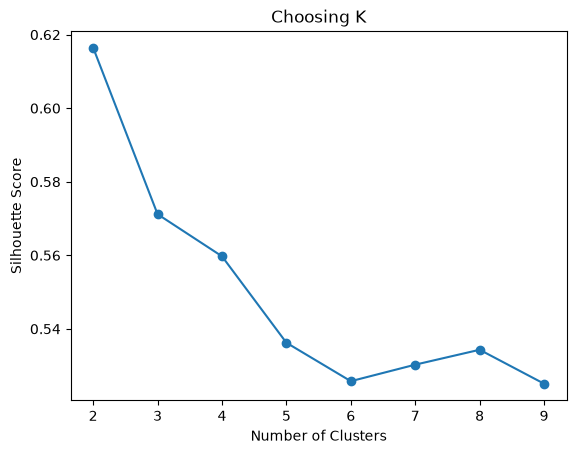

In [5]:
silhouette_scores = []

for k in range(2,10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)


plt.plot(range(2,10), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Choosing K")
plt.show()

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Date,Temperature,Cluster
0,1981-01-01,38.1,2
1,1981-01-02,32.4,2
2,1981-01-03,34.5,2
3,1981-01-04,20.7,1
4,1981-01-05,21.5,1


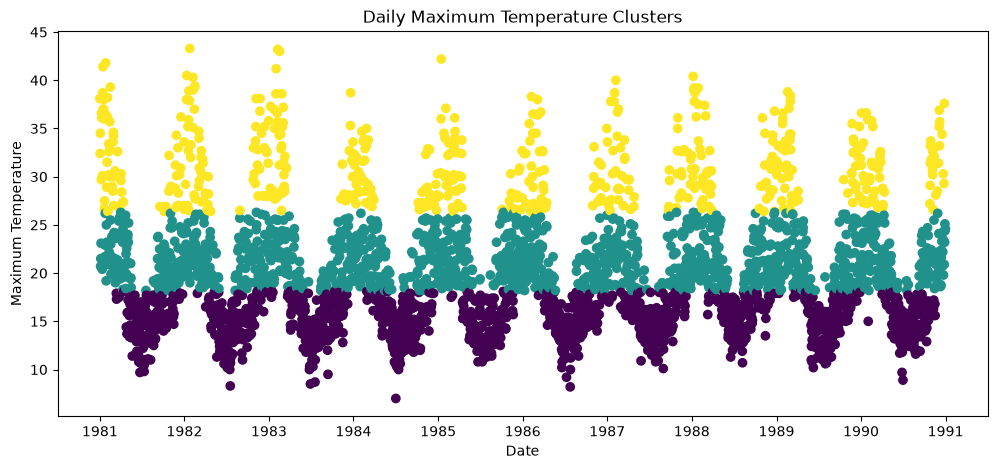

In [7]:
plt.figure(figsize=(12,5))

plt.scatter(
    df["Date"],
    df["Temperature"],
    c=df["Cluster"]
)

plt.xlabel("Date")
plt.ylabel("Maximum Temperature")
plt.title("Daily Maximum Temperature Clusters")

plt.show()

In [8]:
def temperature_description(temp):

    if temp < 15:
        return f"cold day temperature {temp} degrees"
    
    elif temp < 25:
        return f"warm day temperature {temp} degrees"
    
    else:
        return f"hot day temperature {temp} degrees"


df["Temperature_Text"] = df["Temperature"].apply(
    temperature_description
)

df.head()

,Date,Temperature,Cluster,Temperature_Text
0,1981-01-01,38.1,2,hot day temperature 38.1 degrees
1,1981-01-02,32.4,2,hot day temperature 32.4 degrees
2,1981-01-03,34.5,2,hot day temperature 34.5 degrees
3,1981-01-04,20.7,1,warm day temperature 20.7 degrees
4,1981-01-05,21.5,1,warm day temperature 21.5 degrees


In [9]:
vectorizer = TfidfVectorizer()

text_features = vectorizer.fit_transform(
    df["Temperature_Text"]
)

text_features.shape

(3650, 40)

In [10]:
nlp_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["NLP_Cluster"] = nlp_kmeans.fit_predict(
    text_features
)


df.head()

,Date,Temperature,Cluster,Temperature_Text,NLP_Cluster
0,1981-01-01,38.1,2,hot day temperature 38.1 degrees,1
1,1981-01-02,32.4,2,hot day temperature 32.4 degrees,1
2,1981-01-03,34.5,2,hot day temperature 34.5 degrees,1
3,1981-01-04,20.7,1,warm day temperature 20.7 degrees,2
4,1981-01-05,21.5,1,warm day temperature 21.5 degrees,2


In [11]:
df.to_csv(
    "temperature_kmeans_results.csv",
    index=False
)

print("File saved successfully")

File saved successfully
